In [115]:
! pip install langchain langchain-community langgraph python-dotenv faiss-cpu pypdf langchain_google_genai

In [116]:
pip install -U langchain-huggingface sentence-transformers

  Using cached langchain_huggingface-1.2.2-py3-none-any.whl.metadata (4.0 kB)
  Using cached sentence_transformers-6.0.0-py3-none-any.whl.metadata (20 kB)
  Using cached huggingface_hub-1.29.0-py3-none-any.whl.metadata (16 kB)
  Using cached tokenizers-0.23.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.8 kB)
  Using cached transformers-5.16.1-py3-none-any.whl.metadata (32 kB)
  Using cached torch-2.13.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.18.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.32.4-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.6.0-cp38-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
 

In [117]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.messages import HumanMessage, AIMessage , BaseMessage
from langgraph.graph import add_messages
import os
from langchain_community.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.prebuilt import ToolNode , tools_condition

In [118]:
GENAI_API_KEY = os.getenv("GOOGLE_GENAI_KEY")
print(GENAI_API_KEY[:10]+"**************")

AQ.Ab8RN6J**************


In [119]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    google_api_key=GENAI_API_KEY
)

In [120]:
loader = PyPDFLoader("small_rag_test.pdf")
docs = loader.load()

In [121]:
len(docs)

1

In [122]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size = 30,
    chunk_overlap = 10
)

chunks = splitter.split_documents(docs)

In [123]:
len(chunks)

57

In [124]:
embedding_model = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GENAI_API_KEY,
)

In [125]:
vector_store = FAISS.from_documents(chunks, embedding_model)

In [126]:
retriever = vector_store.as_retriever(
    search_type = 'similarity',
    search_kwargs = {'k': 4}
)

In [127]:
@tool
def rag_tool(query):
    
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context' : context,
        'metadata' : metadata
    }

In [128]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [129]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [130]:
def chat_node(state: ChatState):
    mesaages = state['messages']

    response = llm_with_tools.invoke(mesaages)

    return {
        'messages':response
    }

In [131]:
tool_node = ToolNode(tools)

In [132]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

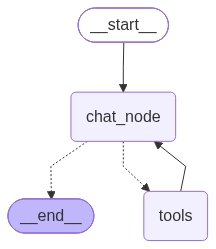

In [133]:
chatbot

In [134]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain RAG"
                )
            )
        ]
    }
)

In [135]:
print(result)

{'messages': [HumanMessage(content='Using the pdf notes, explain RAG', additional_kwargs={}, response_metadata={}, id='35d10553-767b-44bf-97ab-a02ce80be203'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'rag_tool', 'arguments': '{"query": "What is RAG? Explain RAG using the provided document."}'}, '__gemini_function_call_thought_signatures__': {'call_749149': 'EnEKbwERTTIPURfiKAiEq86hXIBl7pz7f5eQQjiiWL7eJHHX+bBijyulSzR/sMCxYvPkEP9RC39MGspBDEhx8CUiq9uoYaK/9LD5TJJiv9YvWSyaei4JakwQPkLJk9D7uV4gwtU1xYpMY/XyDcFqsAEELA=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a04962-0253-7432-9bf4-b1191f31fa43-0', tool_calls=[{'name': 'rag_tool', 'args': {'query': 'What is RAG? Explain RAG using the provided document.'}, 'id': 'call_749149', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 28, 'total_tokens': 104, 'input